# TP3 — Redes Neuronales

Este notebook está organizado en tres secciones principales:

1. **Two Moons** — clasificación binaria no lineal para verificar la capacidad del MLP.
2. **Clasificador en R²** — 4 configuraciones de MLP (M=20/2, con/sin momentum) sobre datos separables y no separables.
3. **ACRIMA** — clasificación de imágenes de fondo de ojo (glaucoma vs. no glaucoma).

**Modelo:** Perceptrón Multicapa con descenso de gradiente con momentum (Bishop, 2006).  
**Configuraciones evaluadas:** M ∈ {2, 20}, γ ∈ {0.0, 0.9}, α = 0.01.

## Configuración del entorno

Se clona el repositorio si se ejecuta en Google Colab, se agrega `src/` al path de Python y se configuran las credenciales de Kaggle necesarias para la Sección 3.

In [2]:
## @brief Configura el entorno de ejecución (Colab o local).
#  Clona el repositorio si se ejecuta en Google Colab y ajusta el directorio de trabajo.
import os, sys
from dotenv import load_dotenv

if 'google.colab' in sys.modules:
    if not os.path.exists('neural-network'):
        os.system('git clone https://github.com/DaniloDuque/neural-network.git')
    if os.path.basename(os.getcwd()) != 'neural-network':
        os.chdir('neural-network')
    os.system('git pull')

sys.path.insert(0, os.path.abspath('src'))

In [3]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        from google.colab import userdata
        os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
        os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')
        print('Credenciales cargadas desde Colab Secrets.')
    except Exception:
        # Corriendo desde VS Code con extensión Colab — usar .env
        load_dotenv()
        print('Credenciales cargadas desde .env (extensión VS Code).')
else:
    kaggle_cfg = os.path.expanduser('~/.config/kaggle/kaggle.json')
    kagglehub_cache = os.path.expanduser('~/.cache/kagglehub/datasets/toaharahmanratul/acrima-dataset')
    if os.path.exists(kaggle_cfg):
        print(f'Credenciales encontradas en {kaggle_cfg}')
    elif os.path.exists(kagglehub_cache):
        print('Dataset ACRIMA ya en caché local — no se requieren credenciales.')
    else:
        print('ADVERTENCIA: no se encontró kaggle.json')

Credenciales cargadas desde .env (extensión VS Code).


## Dependencias

Se instalan las dependencias necesarias para ejecutar el notebook.

In [4]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.7 MB/s eta 0:00:00a 0:00:01


In [5]:
## @brief Instala dependencias adicionales no incluidas en Colab.
import subprocess, sys


subprocess.run([sys.executable, '-m', 'pip', 'install',
                'kagglehub==0.3.13', 'Pillow', '-q'],
               check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'kagglehub==0.3.13', 'Pillow', '-q'], returncode=0)

## Dependencias e importaciones

Se importan todos los módulos del proyecto y se detecta el dispositivo de cómputo.

In [6]:
## @brief Importa todos los módulos del proyecto y configura el entorno.
#  Detecta el dispositivo disponible (CUDA o CPU) para pasarlo a las funciones de biblioteca.
import os
import torch
import random
import optuna
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
from PIL import Image
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import kagglehub

from multilayer_perceptron import MultilayerPerceptron
from data_generator        import generate_data
from data_classifier       import train_all_configs
from visualization         import (plot_datasets, plot_error_matrix,
                                   print_convergence_table, convergence_dataframe)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

FIGURES_DIR = Path('..') / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
RANDOM_SEED=42
import pandas as pd
from xor_classifier        import (CONFIGS, CONVERGENCE_THRESHOLD,
                                    train_xor_configuration, convergence_epoch)


Dispositivo: cpu


---
# Sección 1 — Two Moons: Clasificación Binaria No Lineal

Demostración del MLP sobre el dataset Two Moons para verificar que la red aprende fronteras de decisión no lineales.

In [7]:
## @brief Entrena MLP sobre Two Moons y visualiza la superficie de decisión.
torch.manual_seed(RANDOM_SEED)

X_np, y_np = make_moons(n_samples=400, noise=0.15, random_state=RANDOM_SEED)
X_np = (X_np - X_np.min(0)) / (X_np.max(0) - X_np.min(0))
X_moons = torch.FloatTensor(X_np).to(device)
T_moons = torch.FloatTensor(y_np).unsqueeze(1).to(device)

mlp_moons = MultilayerPerceptron([2, 128, 1], alpha=1.5, gamma=0.95, max_weights=0.01, device=device)

errors, _ = mlp_moons.train_mlp(50000, X_moons, T_moons)

acc = (mlp_moons.predict(X_moons).squeeze().cpu() == torch.tensor(y_np)).float().mean().item()
print(f'Error final: {errors[-1]:.4f}  |  Accuracy: {acc*100:.1f}%')

Error final: 0.0054  |  Accuracy: 99.3%


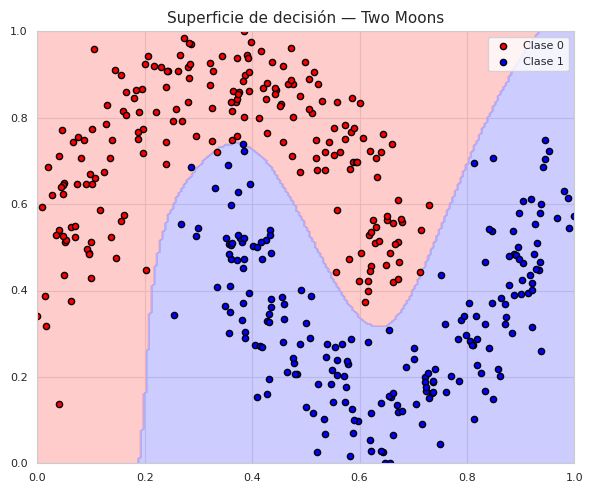

In [8]:
## @brief Visualiza la superficie de decisión del MLP sobre Two Moons.
h = 0.005
xx, yy = np.meshgrid(np.arange(0, 1 + h, h), np.arange(0, 1 + h, h))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
Z = mlp_moons.predict(grid).cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']), alpha=0.6)
plt.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1], c='red',  label='Clase 0', edgecolors='k', s=20)
plt.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1], c='blue', label='Clase 1', edgecolors='k', s=20)
plt.title('Superficie de decisión — Two Moons')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'two_moons.pdf', bbox_inches='tight')
plt.show()

---
# Sección 2 — Clasificación de Función XOR

Se entrena un MLP con arquitectura **[D, M, K] = [2, 2, 1]** sobre la tabla de verdad XOR.
El problema XOR no es linealmente separable: ningún hiperplano en R² puede dividir correctamente
las cuatro muestras. La capa oculta introduce una representación no lineal que permite al modelo
aprender la frontera de decisión correcta.

**Arquitectura:**
- D = 2 neuronas de entrada (x₁, x₂)
- M = 2 neuronas ocultas (representación no lineal)
- K = 1 neurona de salida (predicción binaria)

El bias es manejado internamente por `MultilayerPerceptron`.

In [9]:
## @brief Define el dataset XOR.

X_xor = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
T_xor = torch.tensor([[0.], [1.], [1.], [0.]])
print('Dataset XOR:')
print(torch.cat([X_xor, T_xor], dim=1))

Dataset XOR:
tensor([[0., 0., 0.],
        [0., 1., 1.],
        [1., 0., 1.],
        [1., 1., 0.]])


## 2.1 — Entrenamiento con múltiples configuraciones

In [10]:
## @brief Entrena el MLP XOR con todas las configuraciones de hiperparámetros.
torch.manual_seed(RANDOM_SEED)

xor_results = [train_xor_configuration(alpha, gamma, num_epochs=40000) for alpha, gamma in CONFIGS]

for r in xor_results:
    print(f"α={r['alpha']:.2f}  γ={r['gamma']:.1f}  →  error final: {r['final_error']:.6f}")

α=0.70  γ=0.0  →  error final: 0.000677
α=0.70  γ=1.0  →  error final: 0.000000
α=0.50  γ=0.0  →  error final: 0.250000
α=0.50  γ=0.9  →  error final: 0.000027


## 2.2 — Curvas de aprendizaje

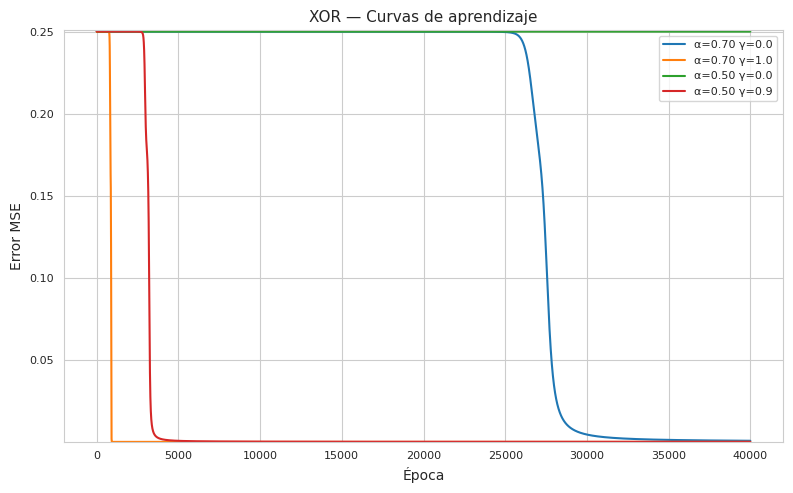

In [11]:
## @brief Genera y guarda las curvas de aprendizaje MSE vs. iteraciones.
fig, ax = plt.subplots(figsize=(8, 5))

maxvalues = [max(r['errors']) for r in xor_results]

max_error = max(maxvalues)
for r in xor_results:
    ax.plot(r['errors'], label=f"α={r['alpha']:.2f} γ={r['gamma']:.1f}")
    # n = 0
    # for err in r['errors']:
    #     if(n%500==0):
    #         print(f"α={r['alpha']:.2f} γ={r['gamma']:.1f}  →  error: {err:.6f}  (época {n})")
    #     n+=1


ax.set_xlabel('Época')
ax.set_ylabel('Error MSE')
ax.set_title('XOR — Curvas de aprendizaje')
ax.legend()
ax.set_yscale('linear')
ax.set_ylim(1e-4, max_error)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'xor_learning_curves.pdf', bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'xor_learning_curves.png', bbox_inches='tight')
plt.show()

## 2.3 — Tabla de resultados

In [12]:
## @brief Construye la tabla comparativa de hiperparámetros y error final.

df_xor = pd.DataFrame([
    {
        'α': r['alpha'],
        'γ': r['gamma'],
        'Error Final': r['final_error'],
        'Época Convergencia': convergence_epoch(r['errors'], CONVERGENCE_THRESHOLD),
    }
    for r in xor_results
])
df_xor

,α,γ,Error Final,Época Convergencia
0,0.7,0.0,0.000677,36334.0
1,0.7,1.0,0.000000,913.0
2,0.5,0.0,0.250000,NaN
3,0.5,0.9,0.000027,4414.0


## 2.4 — Validación final (mejor configuración)

In [13]:
## @brief Evalúa la mejor configuración y muestra las predicciones finales.
best = min(xor_results, key=lambda r: r['final_error'])
print(f"Mejor configuración: α={best['alpha']:.2f}  γ={best['gamma']:.1f}")
print(f"Error final: {best['final_error']:.6f}")
print(f"Época de convergencia: {convergence_epoch(best['errors'], CONVERGENCE_THRESHOLD)}")

preds = best['mlp'].predict(X_xor)

df_val = pd.DataFrame({
    'x₁': X_xor[:, 0].int().tolist(),
    'x₂': X_xor[:, 1].int().tolist(),
    'Esperado': T_xor.squeeze().int().tolist(),
    'Predicción': preds.squeeze().tolist(),
})
df_val

Mejor configuración: α=0.70  γ=1.0
Error final: 0.000000
Época de convergencia: 913


,x₁,x₂,Esperado,Predicción
0,0,0,0,0
1,0,1,1,1
2,1,0,1,1
3,1,1,0,0


---
# Sección 3 — Clasificador de datos en R²

Se generan dos datasets (separable / no-separable) y se entrenan 4 configuraciones de MLP:

| Config | M  | γ   | Descripción               |
|--------|----|-----|---------------------------|
| A      | 20 | 0.9 | 20 neuronas, con momentum |
| B      | 20 | 0.0 | 20 neuronas, sin momentum |
| C      | 2  | 0.9 | 2 neuronas, con momentum  |
| D      | 2  | 0.0 | 2 neuronas, sin momentum  |

Partición 80% entrenamiento / 20% validación. α = 0.01 fijo para todas las configuraciones.

In [14]:
## @brief Define hiperparámetros globales para la sección 2.
NUM_EPOCHS = 50

## 3.1 — Generación de datos

In [15]:
## @brief Genera los datasets separable y no-separable con split 80/20.
X_train_s, X_val_s, T_train_s, T_val_s = generate_data(
    separable=True,  n_samples=500, test_size=0.2, random_state=42,
    device=torch.device(device)
)
X_train_ns, X_val_ns, T_train_ns, T_val_ns = generate_data(
    separable=False, n_samples=500, test_size=0.2, random_state=42,
    device=torch.device(device)
)

print(f'Separable    — train: {X_train_s.shape},  val: {X_val_s.shape}')
print(f'No-separable — train: {X_train_ns.shape}, val: {X_val_ns.shape}')

Separable    — train: torch.Size([400, 2]),  val: torch.Size([100, 2])
No-separable — train: torch.Size([400, 2]), val: torch.Size([100, 2])


## 3.2 — Visualización de los datos

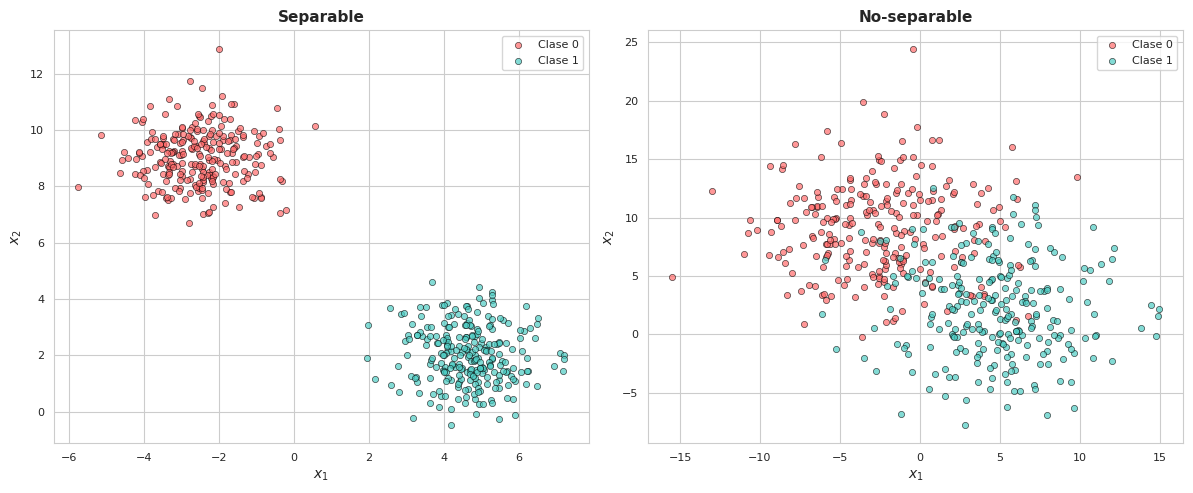

In [16]:
## @brief Muestra scatter de ambos datasets (train + val combinados).
X_sep_full   = torch.cat([X_train_s,  X_val_s],  dim=0).cpu()
T_sep_full   = torch.cat([T_train_s,  T_val_s],  dim=0).cpu()
X_nosep_full = torch.cat([X_train_ns, X_val_ns], dim=0).cpu()
T_nosep_full = torch.cat([T_train_ns, T_val_ns], dim=0).cpu()

fig = plot_datasets(X_sep_full, T_sep_full, X_nosep_full, T_nosep_full,
                    output_path=FIGURES_DIR / 'datasets_scatter.pdf')
plt.show()

## 3.3 — Entrenamiento de las 4 configuraciones

In [17]:
## @brief Entrena las 4 configuraciones sobre el dataset separable.
results_sep = train_all_configs(
    X_train_s, T_train_s, X_val_s, T_val_s,
    num_epochs=NUM_EPOCHS
)

In [18]:
## @brief Entrena las 4 configuraciones sobre el dataset no-separable.
results_nosep = train_all_configs(
    X_train_ns, T_train_ns, X_val_ns, T_val_ns,
    num_epochs=NUM_EPOCHS
)

## 3.4 — Evolución del error

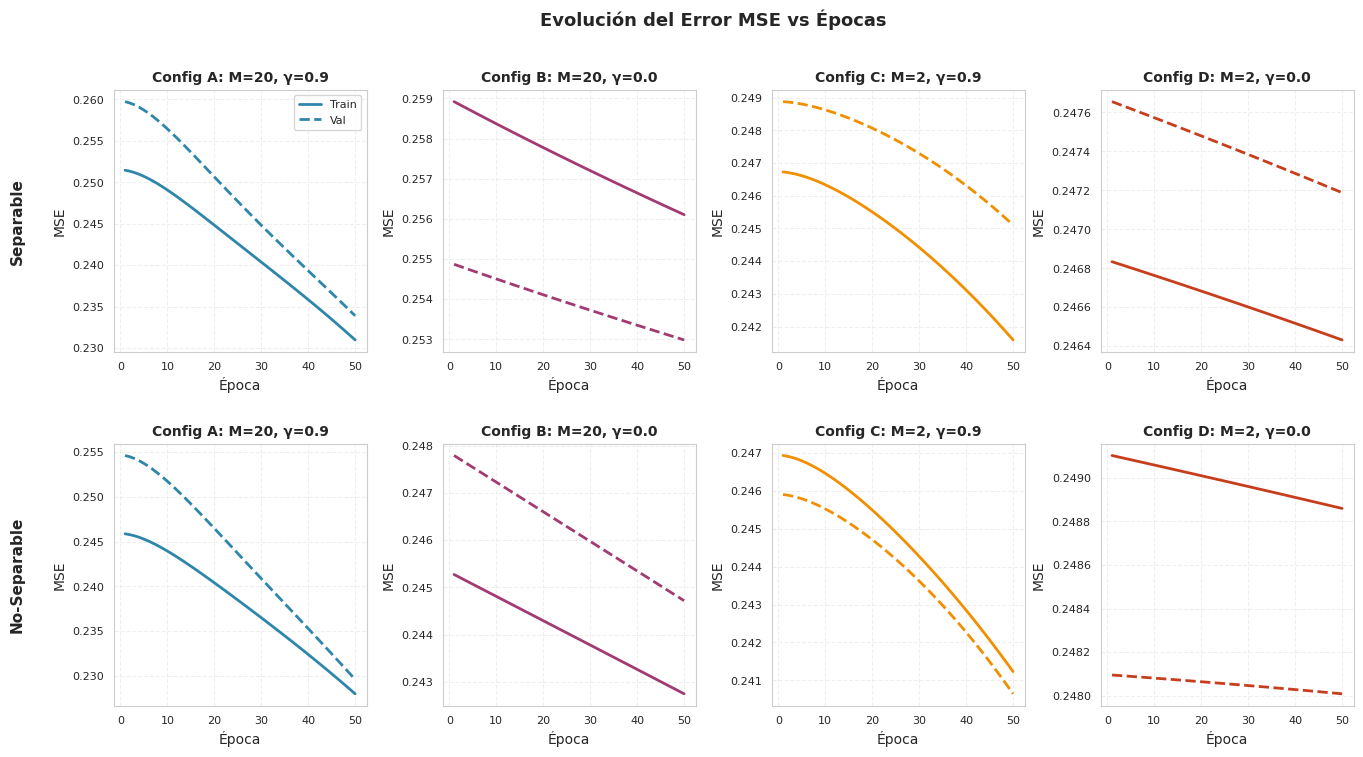

In [19]:
## @brief Genera la matriz 2×4 de curvas de error train/val por configuración.
fig = plot_error_matrix(results_sep, results_nosep,
                        output_path=FIGURES_DIR / 'error_matrix.pdf')
plt.show()

## 3.5 — Tabla de convergencia

In [20]:
## @brief Imprime la tabla de errores finales de validación por configuración.
print_convergence_table(results_sep, results_nosep)
convergence_dataframe(results_sep, results_nosep)


Config        Separable (val)   No-Separable (val)
----------------------------------------------------
Config A             0.233898             0.229580
Config B             0.252984             0.244721
Config C             0.245104             0.240645
Config D             0.247188             0.248009


,config,sep_train,sep_val,nosep_train,nosep_val
0,A,0.230979,0.233898,0.227975,0.229580
1,B,0.256104,0.252984,0.242752,0.244721
2,C,0.241589,0.245104,0.241231,0.240645
3,D,0.246432,0.247188,0.248860,0.248009


---
# Sección 4 — Clasificador de imágenes ACRIMA

Dataset: [ACRIMA en Kaggle](https://www.kaggle.com/datasets/toaharahmanratul/acrima-dataset) — imágenes de fondo de ojo etiquetadas con y sin glaucoma.

## 2. Carga del Dataset ACRIMA (inciso 1a)
Dataset: https://www.kaggle.com/datasets/toaharahmanratul/acrima-dataset

Estructura esperada:
```
./data/acrima/
    Glaucoma/   ← imágenes con glaucoma
    Normal/     ← imágenes sin glaucoma
```


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models

from sklearn.metrics import accuracy_score, classification_report

from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [22]:
import kagglehub

ACRIMA_PATH = kagglehub.dataset_download("toaharahmanratul/acrima-dataset")

print(ACRIMA_PATH)

Using Colab cache for faster access to the 'acrima-dataset' dataset.
/kaggle/input/acrima-dataset


In [23]:
def encontrar_directorio_dataset(base_path):
    """Busca recursivamente las carpetas Glaucoma/Normal."""
    base = Path(base_path)
    for folder in base.rglob("*"):
        if folder.is_dir() and folder.name.lower() in ["glaucoma", "normal", "g", "n"]:
            parent = folder.parent
            hijos = [d.name.lower() for d in parent.iterdir() if d.is_dir()]
            if any("glaucoma" in h or h == "g" for h in hijos) and                any("normal" in h or h == "n" for h in hijos):
                print(f"Directorio de clases: {parent}")
                return parent
    return base

train_dir = encontrar_directorio_dataset(ACRIMA_PATH)/"train"
test_dir  = Path(ACRIMA_PATH) / "test"


## 3. Dataset personalizado con normalización ℓ∞ (inciso 1a)

**Normalización ℓ∞ por observación:**
$$x_{norm} = \frac{x}{\|x\|_{\infty}} = \frac{x}{\max(x)}$$

Cada imagen se divide por su propio valor máximo de píxel, garantizando que **todos los valores queden en [0, 1]** preservando la distribución relativa de intensidades dentro de cada imagen.


In [ ]:
class ACRIMADataset(Dataset):
    """
    Dataset ACRIMA con normalización ℓ∞ por observación.
    
    Normalización: x_norm = x / max(x)
    - Garantiza valores ∈ [0, 1]
    - Preserva distribución relativa de intensidades por imagen
    - Es una normalización local (por observación), no global
    """
    CLASES = ["Normal", "Glaucoma"]

    def __init__(self, root_dir, img_size=(128, 128)):
        self.root_dir = Path(root_dir)
        self.img_size = img_size
        self.samples, self.labels = [], []

        carpetas_clase = {}
        for d in self.root_dir.iterdir():
            if d.is_dir():
                nombre = d.name.lower()
                if "glaucoma" in nombre and "non" not in nombre:
                    carpetas_clase[1] = d

                elif (
                    "normal" in nombre
                    or "non glaucoma" in nombre
                    or nombre == "n"
                ):
                    carpetas_clase[0] = d

        if len(carpetas_clase) < 2:
            raise ValueError(f"Se necesitan 2 clases, encontradas: {list(carpetas_clase.keys())}")

        for label, carpeta in sorted(carpetas_clase.items()):
            ext = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
            imgs = [f for f in carpeta.rglob("*") if f.suffix.lower() in ext]
            print(f"  {self.CLASES[label]}: {len(imgs)} imágenes")
            for p in imgs:
                self.samples.append((p, label))
                self.labels.append(label)

        print(f"Total: {len(self.samples)} muestras")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB").resize(self.img_size, Image.LANCZOS)
        img_tensor = torch.tensor(np.array(img), dtype=torch.float32)  # (H, W, 3)

        # ── NORMALIZACIÓN ℓ∞ ──────────────────────────────────────────────
        max_val = img_tensor.max()
        if max_val > 0:
            img_tensor = img_tensor / max_val   # ∈ [0, 1]
        # ──────────────────────────────────────────────────────────────────

        return img_tensor.permute(2, 0, 1), label  # (C, H, W)


# Crear datasets
print("Dataset de entrenamiendo:")
dataset_train_mlp  = ACRIMADataset(train_dir, img_size=(64, 64))
dataset_train_alex = ACRIMADataset(train_dir, img_size=(224, 224))

print("Dataset de pruebas:")
dataset_test_mlp  = ACRIMADataset(test_dir, img_size=(64, 64))
dataset_test_alex = ACRIMADataset(test_dir, img_size=(224, 224))


  Normal: 239 imágenes
  Glaucoma: 326 imágenes
Total: 565 muestras
  Normal: 239 imágenes
  Glaucoma: 326 imágenes
Total: 565 muestras
  Normal: 70 imágenes
  Glaucoma: 70 imágenes
Total: 140 muestras
  Normal: 70 imágenes
  Glaucoma: 70 imágenes
Total: 140 muestras


## 4. Documentación de la normalización (inciso 1a-1)
### Prueba 1: Verificación numérica — max(img_normalizada) ≈ 1.0
### Prueba 2: Comparación visual original vs normalizada
### Prueba 3: Estadísticas por clase


In [26]:
# ═══ PRUEBA 1: Verificación numérica ═══════════════════════════════════════
print("PRUEBA 1 — Verificación numérica: max(img_norm) debe ser ≈ 1.0")
print(f"{'Idx':>4} | {'Max original':>13} | {'Max norm':>10} | {'Min norm':>9} | OK")
print("-"*55)

resultados = []
for i in range(min(10, len(dataset_train_mlp))):
    img_path, _ = dataset_train_mlp.samples[i]
    arr_raw = np.array(Image.open(img_path).convert("RGB").resize((64,64)), dtype=np.float32)
    max_raw = arr_raw.max()

    img_norm, _ = dataset_train_mlp[i]
    max_n = img_norm.max().item()
    min_n = img_norm.min().item()
    ok = abs(max_n - 1.0) < 1e-5 if max_raw > 0 else True
    resultados.append(ok)
    print(f"{i:>4} | {max_raw:>13.2f} | {max_n:>10.6f} | {min_n:>9.6f} | {'✓' if ok else '✗'}")

print(f"\nResultado: {'PASÓ ✓' if all(resultados) else 'FALLÓ ✗'} ({sum(resultados)}/{len(resultados)})")


PRUEBA 1 — Verificación numérica: max(img_norm) debe ser ≈ 1.0
 Idx |  Max original |   Max norm |  Min norm | OK
-------------------------------------------------------
   0 |        198.00 |   1.000000 |  0.025126 | ✓
   1 |        255.00 |   1.000000 |  0.050980 | ✓
   2 |        220.00 |   1.000000 |  0.000000 | ✓
   3 |        173.00 |   1.000000 |  0.040230 | ✓
   4 |        248.00 |   1.000000 |  0.064516 | ✓
   5 |        255.00 |   1.000000 |  0.015686 | ✓
   6 |        255.00 |   1.000000 |  0.011765 | ✓
   7 |        255.00 |   1.000000 |  0.003922 | ✓
   8 |        255.00 |   1.000000 |  0.082353 | ✓
   9 |        255.00 |   1.000000 |  0.000000 | ✓

Resultado: PASÓ ✓ (10/10)


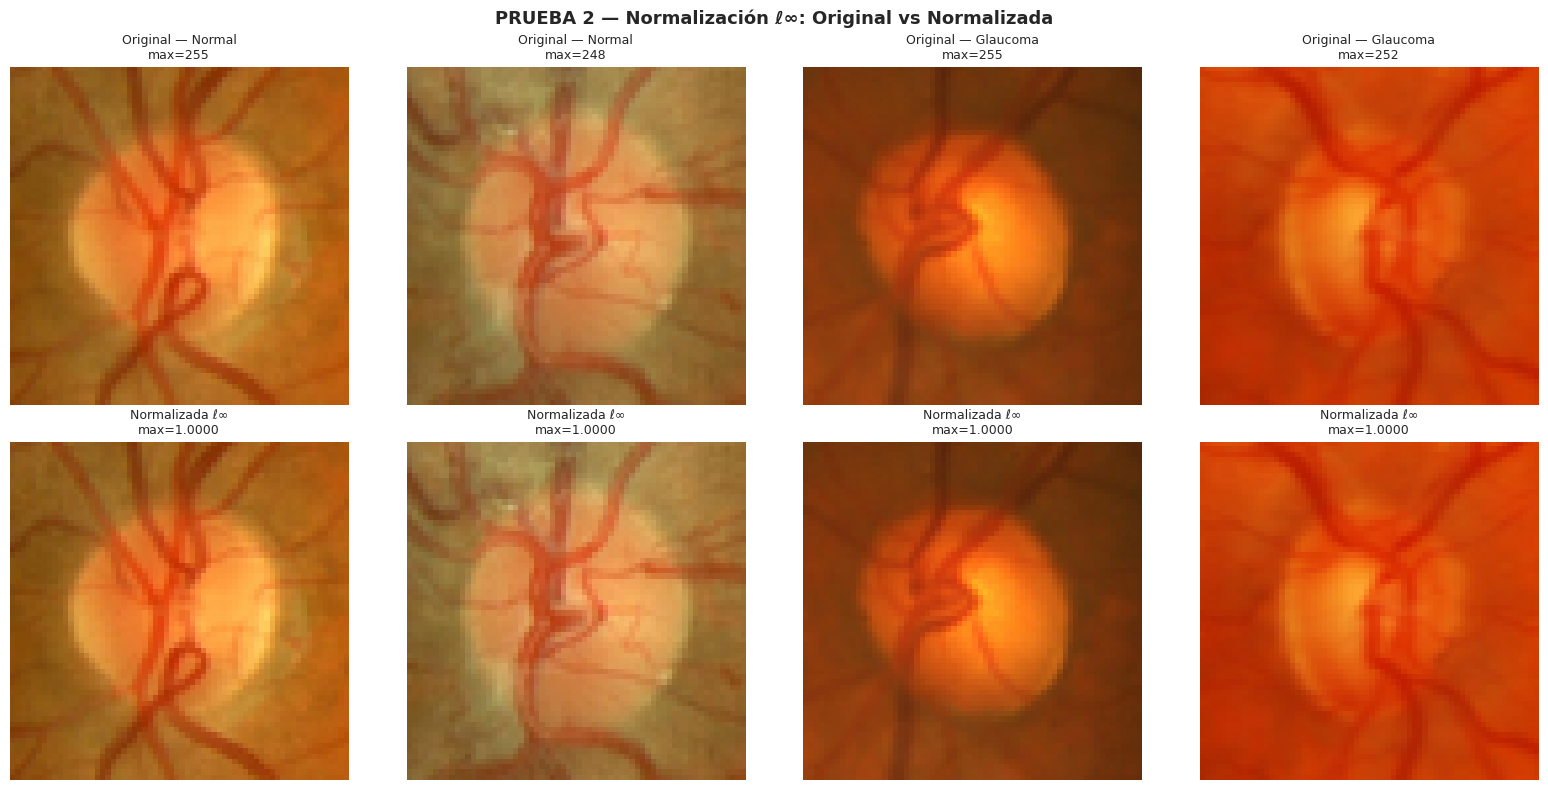

✓ Figura guardada: prueba_normalizacion.png


In [27]:
# ═══ PRUEBA 2: Verificación visual ═════════════════════════════════════════
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("PRUEBA 2 — Normalización ℓ∞: Original vs Normalizada", fontsize=13, fontweight='bold')

indices = random.sample(range(len(dataset_train_mlp)), 4)
for col, idx in enumerate(indices):
    img_path, label = dataset_train_mlp.samples[idx]
    clase = dataset_train_mlp.CLASES[label]
    
    img_raw = np.array(Image.open(img_path).convert("RGB").resize((64, 64)))
    axes[0, col].imshow(img_raw)
    axes[0, col].set_title(f"Original — {clase}\nmax={img_raw.max()}", fontsize=9)
    axes[0, col].axis("off")

    img_norm, _ = dataset_train_mlp[idx]
    img_norm_np = img_norm.permute(1, 2, 0).numpy()
    axes[1, col].imshow(img_norm_np)
    axes[1, col].set_title(f"Normalizada ℓ∞\nmax={img_norm_np.max():.4f}", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig("prueba_normalizacion.png", dpi=120, bbox_inches='tight')
plt.show()
print("✓ Figura guardada: prueba_normalizacion.png")


In [28]:
# ═══ PRUEBA 3: Estadísticas por clase ══════════════════════════════════════
print("PRUEBA 3 — Estadísticas de imágenes normalizadas por clase (50 muestras)")
stats = {c: {"min": [], "max": [], "mean": []} for c in dataset_train_mlp.CLASES}

for i in range(min(50, len(dataset_train_mlp))):
    img_norm, label = dataset_train_mlp[i]
    clase = dataset_train_mlp.CLASES[label]
    stats[clase]["min"].append(img_norm.min().item())
    stats[clase]["max"].append(img_norm.max().item())
    stats[clase]["mean"].append(img_norm.mean().item())

for clase, s in stats.items():
    if s["max"]:
        print(f"  {clase:10}: min_medio={np.mean(s['min']):.4f} | "
              f"max_medio={np.mean(s['max']):.4f} (debe ≈1.0) | "
              f"mean_medio={np.mean(s['mean']):.4f}")


PRUEBA 3 — Estadísticas de imágenes normalizadas por clase (50 muestras)
  Normal    : min_medio=0.0249 | max_medio=1.0000 (debe ≈1.0) | mean_medio=0.4309


## 5. Configuraciones D, M, T (inciso 1b)

Se definen 3 configuraciones con diferentes tamaños de capa oculta M.
- **D** (entrada): `H × W × C = 64 × 64 × 3 = 12,288` neuronas
- **T** (salida): `2` clases (Normal / Glaucoma)
- **M** (oculta): varía entre configuraciones


In [30]:
H, W, C = 64, 64, 3
D = H * W * C   # 12288
T = 2           # clases

CONFIGURACIONES = [
    {"nombre": "Config-1 (Pequeña)",  "D": D, "M": 256,  "T": T},
    {"nombre": "Config-2 (Media)",    "D": D, "M": 512,  "T": T},
    {"nombre": "Config-3 (Grande)",   "D": D, "M": 1024, "T": T},
]

print("Configuraciones definidas:")
print(f"{'Nombre':<25} | {'D':>7} | {'M':>6} | {'T':>4} | {'Parámetros':>12}")
print("-"*65)
for c in CONFIGURACIONES:
    params = (c['D']*c['M']+c['M']) + (c['M']*c['T']+c['T'])
    print(f"{c['nombre']:<25} | {c['D']:>7,} | {c['M']:>6,} | {c['T']:>4} | {params:>12,}")


Configuraciones definidas:
Nombre                    |       D |      M |    T |   Parámetros
-----------------------------------------------------------------
Config-1 (Pequeña)        |  12,288 |    256 |    2 |    3,146,498
Config-2 (Media)          |  12,288 |    512 |    2 |    6,292,994
Config-3 (Grande)         |  12,288 |  1,024 |    2 |   12,585,986


## 6. Definición del MLP

In [31]:
DEVICE = device
class MLP(nn.Module):
    """
    Red D → M → T con activación ReLU.
    Parámetros:
      D: dimensión de entrada (píxeles aplanados)
      M: neuronas en capa oculta
      T: neuronas de salida (= clases)
    """
    def __init__(self, D, M, T):
        super().__init__()
        self.red = nn.Sequential(
            nn.Flatten(),
            nn.Linear(D, M),
            nn.ReLU(),
            nn.Linear(M, T)
        )
    def forward(self, x): return self.red(x)

# Función de entrenamiento genérica
def entrenar(modelo, train_loader, val_loader, alpha=0.001, epochs=50, nombre=""):
    criterio = nn.CrossEntropyLoss()
    opt = optim.Adam(modelo.parameters(), lr=alpha)
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    modelo = modelo.to(DEVICE)
    for epoch in range(1, epochs + 1):
        modelo.train()
        tl, tc, tn = 0.0, 0, 0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            out = modelo(X); loss = criterio(out, y)
            loss.backward(); opt.step()
            tl += loss.item()*len(y); tc += (out.argmax(1)==y).sum().item(); tn += len(y)
        modelo.eval(); vl, vc, vn = 0.0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                out = modelo(X); loss = criterio(out, y)
                vl += loss.item()*len(y); vc += (out.argmax(1)==y).sum().item(); vn += len(y)
        hist["train_loss"].append(tl/tn); hist["val_loss"].append(vl/vn)
        hist["train_acc"].append(tc/tn);  hist["val_acc"].append(vc/vn)
        if epoch % 10 == 0 or epoch == 1:
            print(f"  [{nombre}] Época {epoch:>3}/{epochs} | "
                  f"TLoss={hist['train_loss'][-1]:.4f} TAcc={hist['train_acc'][-1]:.3f} | "
                  f"VLoss={hist['val_loss'][-1]:.4f} VAcc={hist['val_acc'][-1]:.3f}")
    return hist

def graficar_curvas(historias, nombres, titulo="Curvas de Aprendizaje"):
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(titulo, fontsize=13, fontweight='bold')
    cols = plt.cm.tab10.colors
    for i, (h, n) in enumerate(zip(historias, nombres)):
        c = cols[i % len(cols)]
        ax[0].plot(h["train_loss"], color=c, label=f"{n} train", lw=2)
        ax[0].plot(h["val_loss"],   color=c, label=f"{n} val", ls="--", lw=2)
        ax[1].plot(h["train_acc"],  color=c, label=f"{n} train", lw=2)
        ax[1].plot(h["val_acc"],    color=c, label=f"{n} val", ls="--", lw=2)
    for a, ylabel, t in zip(ax, ["Loss", "Accuracy"], ["Pérdida", "Exactitud"]):
        a.set_xlabel("Épocas"); a.set_ylabel(ylabel); a.set_title(t)
        a.legend(fontsize=8); a.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = titulo.replace(" ","_") + ".png"
    plt.savefig(fname, dpi=120, bbox_inches='tight'); plt.show()
    print(f"Guardado: {fname}")


## 7. Heurísticas y entrenamiento (inciso 1c)

**Heurísticas utilizadas:**
| Hiperparámetro | Heurística | Valor elegido |
|---|---|---|
| M | Entre √(D·T) y D/2 | 256 / 512 / 1024 |
| α | Adam estándar | 0.001 |
| P | Hasta convergencia (~50 épocas) | 50 |


In [32]:
# Partición 80/20
SEED = 42

indices = list(range(len(dataset_train_mlp)))
idx_train, idx_val = train_test_split(indices, test_size=0.2,
                                       stratify=dataset_train_mlp.labels, random_state=SEED)
train_loader = DataLoader(Subset(dataset_train_mlp, idx_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(Subset(dataset_train_mlp, idx_val),   batch_size=32)
print(f"Train: {len(idx_train)} | Val: {len(idx_val)}")

# Documentar heurísticas
print("\nHeurísticas calibradas:")
for c in CONFIGURACIONES:
    params = (c['D']*c['M']+c['M']) + (c['M']*c['T']+c['T'])
    print(f"  {c['nombre']:25}: M={c['M']}, α=0.001, P=50 | √(D·T)={int((c['D']*c['T'])**0.5)}")


Train: 452 | Val: 113

Heurísticas calibradas:
  Config-1 (Pequeña)       : M=256, α=0.001, P=50 | √(D·T)=156
  Config-2 (Media)         : M=512, α=0.001, P=50 | √(D·T)=156
  Config-3 (Grande)        : M=1024, α=0.001, P=50 | √(D·T)=156



→ Entrenando Config-1 (Pequeña)
  [Config-1 (Pequeña)] Época   1/50 | TLoss=1.6639 TAcc=0.529 | VLoss=0.6073 VAcc=0.628
  [Config-1 (Pequeña)] Época  10/50 | TLoss=0.3194 TAcc=0.865 | VLoss=0.3026 VAcc=0.920
  [Config-1 (Pequeña)] Época  20/50 | TLoss=0.2122 TAcc=0.907 | VLoss=0.1996 VAcc=0.938
  [Config-1 (Pequeña)] Época  30/50 | TLoss=0.1677 TAcc=0.934 | VLoss=0.2247 VAcc=0.876
  [Config-1 (Pequeña)] Época  40/50 | TLoss=0.1439 TAcc=0.947 | VLoss=0.1475 VAcc=0.938
  [Config-1 (Pequeña)] Época  50/50 | TLoss=0.1327 TAcc=0.947 | VLoss=0.1588 VAcc=0.920

→ Entrenando Config-2 (Media)
  [Config-2 (Media)] Época   1/50 | TLoss=1.8246 TAcc=0.511 | VLoss=0.6314 VAcc=0.611
  [Config-2 (Media)] Época  10/50 | TLoss=0.3196 TAcc=0.861 | VLoss=0.3420 VAcc=0.779
  [Config-2 (Media)] Época  20/50 | TLoss=0.2087 TAcc=0.909 | VLoss=0.2511 VAcc=0.867
  [Config-2 (Media)] Época  30/50 | TLoss=0.1798 TAcc=0.931 | VLoss=0.2031 VAcc=0.903
  [Config-2 (Media)] Época  40/50 | TLoss=0.1391 TAcc=0.938 | VL

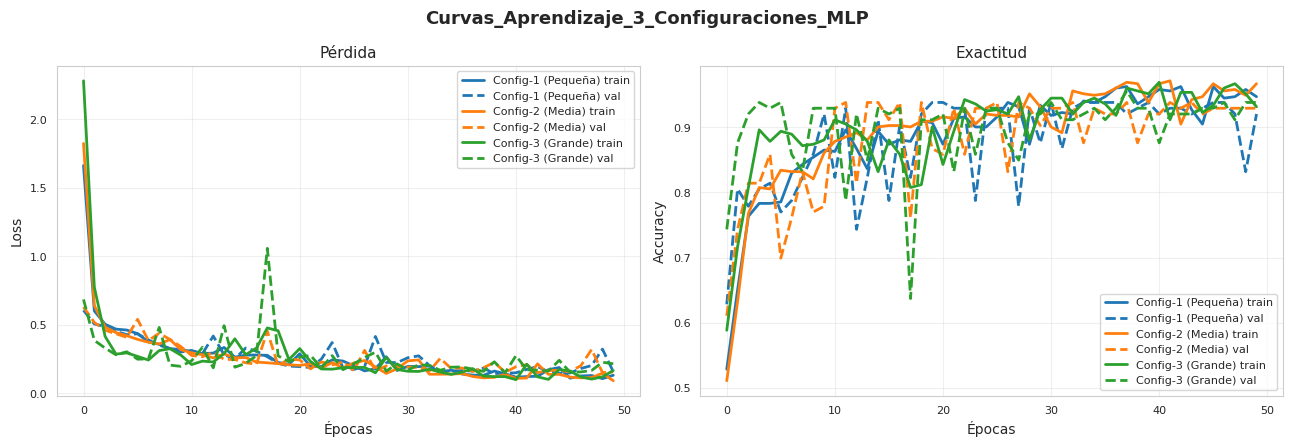

Guardado: Curvas_Aprendizaje_3_Configuraciones_MLP.png


In [33]:
# Entrenar las 3 configuraciones
historias, nombres_h = [], []
for c in CONFIGURACIONES:
    print(f"\n→ Entrenando {c['nombre']}")
    m = MLP(c['D'], c['M'], c['T'])
    h = entrenar(m, train_loader, val_loader, alpha=0.001, epochs=50, nombre=c['nombre'])
    historias.append(h); nombres_h.append(c['nombre'])

graficar_curvas(historias, nombres_h, "Curvas_Aprendizaje_3_Configuraciones_MLP")

## 8. Calibración con Optuna — MLP (inciso 1d)
Se calibran **γ** (weight_decay) y **α** (learning rate) con P=50 épocas.


In [35]:
def objetivo_mlp(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 1e-1, log=True)
    gamma = trial.suggest_float("gamma", 1e-6, 1e-2, log=True)
    M     = trial.suggest_categorical("M", [128, 256, 512, 1024])
    
    m = MLP(D, M, T).to(DEVICE)
    criterio = nn.CrossEntropyLoss()
    opt = optim.Adam(m.parameters(), lr=alpha, weight_decay=gamma)
    
    for epoch in range(10):
        m.train()
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); criterio(m(X), y).backward(); opt.step()
        m.eval(); vl, n = 0.0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.to(DEVICE)
                vl += criterio(m(X), y).item() * len(y); n += len(y)
        vl /= n
        trial.report(vl, epoch)
        if trial.should_prune(): raise optuna.exceptions.TrialPruned()
    return vl

optuna.logging.set_verbosity(optuna.logging.WARNING)
estudio_mlp = optuna.create_study(direction="minimize",
                                    pruner=optuna.pruners.MedianPruner())
estudio_mlp.optimize(objetivo_mlp, n_trials=20, show_progress_bar=True)

print(f"\n✓ Mejor trial #{estudio_mlp.best_trial.number}")
print(f"  Val Loss: {estudio_mlp.best_value:.6f}")
for k, v in estudio_mlp.best_params.items():
    print(f"  {k}: {v}")


  0%|          | 0/20 [00:00<?, ?it/s]


✓ Mejor trial #2
  Val Loss: 0.240139
  alpha: 0.0007827375163075103
  gamma: 3.216891398336802e-05
  M: 1024


  [MLP-Optuna] Época   1/50 | TLoss=2.6961 TAcc=0.491 | VLoss=0.9832 VAcc=0.575
  [MLP-Optuna] Época  10/50 | TLoss=0.3106 TAcc=0.872 | VLoss=0.3536 VAcc=0.894
  [MLP-Optuna] Época  20/50 | TLoss=0.3003 TAcc=0.865 | VLoss=0.3069 VAcc=0.814
  [MLP-Optuna] Época  30/50 | TLoss=0.2145 TAcc=0.920 | VLoss=0.1883 VAcc=0.938
  [MLP-Optuna] Época  40/50 | TLoss=0.1446 TAcc=0.947 | VLoss=0.1761 VAcc=0.929
  [MLP-Optuna] Época  50/50 | TLoss=0.1125 TAcc=0.958 | VLoss=0.1906 VAcc=0.938


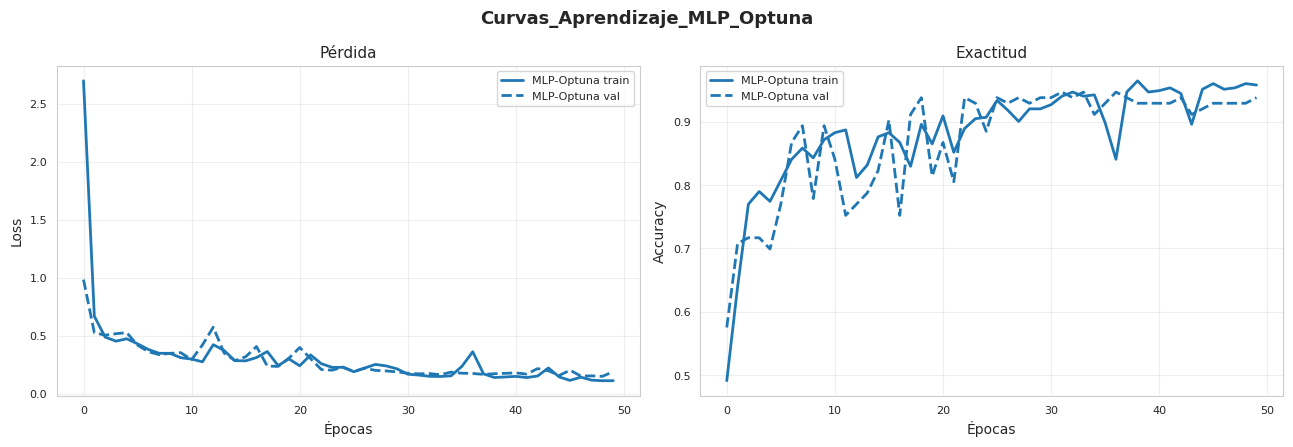

Guardado: Curvas_Aprendizaje_MLP_Optuna.png


In [36]:
# Curva de aprendizaje con mejores parámetros Optuna
bp = estudio_mlp.best_params
m_opt = MLP(D, bp.get('M', 512), T)
hist_opt = entrenar(m_opt, train_loader, val_loader,
                    alpha=bp['alpha'], epochs=50, nombre="MLP-Optuna")
graficar_curvas([hist_opt], ["MLP-Optuna"],
                "Curvas_Aprendizaje_MLP_Optuna")


## 9. AlexNet adaptada (Punto 2)

**Modificaciones documentadas de la arquitectura original:**

| Componente | AlexNet original | Modificación para ACRIMA |
|---|---|---|
| Capa de salida | `Linear(4096, 1000)` (ImageNet) | `Linear(4096, 2)` (Normal/Glaucoma) |
| Pesos iniciales | Aleatorios | Preentrenados en ImageNet (transfer learning) |
| Tamaño entrada | 224×224 | 224×224 (sin cambios) |
| Dropout | p=0.5 | p=0.5 (sin cambios) |


In [37]:
class AlexNetGlaucoma(nn.Module):
    """
    AlexNet del zoo de PyTorch adaptada para ACRIMA.
    
    MODIFICACIÓN PRINCIPAL:
      Reemplaza la capa final classifier[-1]: Linear(4096, 1000)
      por:                                    Linear(4096, 2)
    Esto adapta la red de 1000 clases (ImageNet) a 2 clases (Normal/Glaucoma).
    """
    def __init__(self, n_clases=2, preentrenado=True):
        super().__init__()
        weights = models.AlexNet_Weights.IMAGENET1K_V1 if preentrenado else None
        self.backbone = models.alexnet(weights=weights)
        
        # ── Modificación: reemplazar clasificador final ─────────────────
        in_f = self.backbone.classifier[-1].in_features  # 4096
        self.backbone.classifier[-1] = nn.Linear(in_f, n_clases)
        # ────────────────────────────────────────────────────────────────

    def forward(self, x): return self.backbone(x)

alex = AlexNetGlaucoma(preentrenado=True)
print("Arquitectura del clasificador de AlexNet modificada:")
print(alex.backbone.classifier)
total = sum(p.numel() for p in alex.parameters())
print(f"\nParámetros totales : {total:,}")
print(f"Capa de salida     : Linear(4096 → 2)")


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 124MB/s]  


Arquitectura del clasificador de AlexNet modificada:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=2, bias=True)
)

Parámetros totales : 57,012,034
Capa de salida     : Linear(4096 → 2)


## 10. Calibración Optuna — AlexNet (inciso 2a)

In [ ]:
# Partición para AlexNet
idx_train_a, idx_val_a = train_test_split(
    list(range(len(dataset_train_alex))), test_size=0.2,
    stratify=dataset_train_alex.labels, random_state=SEED)
train_alex = DataLoader(Subset(dataset_train_alex, idx_train_a), batch_size=16, shuffle=True)
val_alex   = DataLoader(Subset(dataset_train_alex, idx_val_a),   batch_size=16)

def objetivo_alex(trial):
    lr  = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    wd  = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    opt_n = trial.suggest_categorical("opt", ["Adam", "SGD", "AdamW"])
    
    m = AlexNetGlaucoma(preentrenado=True).to(DEVICE)
    criterio = nn.CrossEntropyLoss()
    if opt_n == "SGD":
        mom = trial.suggest_float("momentum", 0.8, 0.99)
        opt = optim.SGD(m.parameters(), lr=lr, weight_decay=wd, momentum=mom)
    elif opt_n == "AdamW":
        opt = optim.AdamW(m.parameters(), lr=lr, weight_decay=wd)
    else:
        opt = optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    
    for epoch in range(15):
        m.train()
        for X, y in train_alex:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); criterio(m(X), y).backward(); opt.step()
        m.eval(); vl, n = 0.0, 0
        with torch.no_grad():
            for X, y in val_alex:
                X, y = X.to(DEVICE), y.to(DEVICE)
                vl += criterio(m(X), y).item()*len(y); n += len(y)
        vl /= n
        trial.report(vl, epoch)
        if trial.should_prune(): raise optuna.exceptions.TrialPruned()
    return vl

estudio_alex = optuna.create_study(direction="minimize",
                                    pruner=optuna.pruners.MedianPruner())
estudio_alex.optimize(objetivo_alex, n_trials=15, show_progress_bar=True)

print(f"\n✓ Mejor trial #{estudio_alex.best_trial.number}")
print(f"  Val Loss: {estudio_alex.best_value:.6f}")
for k, v in estudio_alex.best_params.items(): print(f"  {k}: {v}")


  0%|          | 0/15 [00:00<?, ?it/s]

In [ ]:
# Curva de aprendizaje AlexNet con mejores parámetros
bp_a = estudio_alex.best_params
alex_final = AlexNetGlaucoma(preentrenado=True)
hist_alex = entrenar(alex_final, train_alex, val_alex,
                     alpha=bp_a.get('lr', 1e-4), epochs=20, nombre="AlexNet")
graficar_curvas([hist_alex], ["AlexNet"], "Curvas_Aprendizaje_AlexNet_Optuna")


## 11. Evaluación con 10 particiones 80/20 (inciso 2b)

In [ ]:
print("Evaluando con 10 particiones 80/20...")
bp_mlp  = estudio_mlp.best_params
bp_alex = estudio_alex.best_params
resultados_mlp, resultados_alex = [], []

for part in range(10):
    seed_p = SEED + part
    # ── MLP ────────────────────────────────────────────────────────────────
    idxt, idxte = train_test_split(list(range(len(dataset_train_mlp))),
                                    test_size=0.2, stratify=dataset_train_mlp.labels,
                                    random_state=seed_p)
    tl = DataLoader(Subset(dataset_train_mlp, idxt),  batch_size=32, shuffle=True)
    te = DataLoader(Subset(dataset_train_mlp, idxte), batch_size=32)
    m = MLP(D, bp_mlp.get('M', 512), T).to(DEVICE)
    o = optim.Adam(m.parameters(), lr=bp_mlp.get('alpha', 0.001),
                   weight_decay=bp_mlp.get('gamma', 1e-4))
    for _ in range(30):
        m.train()
        for X, y in tl:
            X, y = X.to(DEVICE), y.to(DEVICE)
            o.zero_grad(); nn.CrossEntropyLoss()(m(X),y).backward(); o.step()
    m.eval(); preds, labs = [], []
    with torch.no_grad():
        for X, y in te:
            preds.extend(m(X.to(DEVICE)).argmax(1).cpu().tolist())
            labs.extend(y.tolist())
    resultados_mlp.append(accuracy_score(labs, preds))
    
    # ── AlexNet ────────────────────────────────────────────────────────────
    idxta, idxtea = train_test_split(list(range(len(dataset_train_mlp))),
                                      test_size=0.2, stratify=dataset_train_mlp.labels,
                                      random_state=seed_p)
    tla = DataLoader(Subset(dataset_train_mlp, idxta),  batch_size=16, shuffle=True)
    tea = DataLoader(Subset(dataset_train_mlp, idxtea), batch_size=16)
    a = AlexNetGlaucoma(preentrenado=True).to(DEVICE)
    oa = optim.Adam(a.parameters(), lr=bp_alex.get('lr', 1e-4),
                    weight_decay=bp_alex.get('weight_decay', 1e-4))
    for _ in range(15):
        a.train()
        for X, y in tla:
            X, y = X.to(DEVICE), y.to(DEVICE)
            oa.zero_grad(); nn.CrossEntropyLoss()(a(X),y).backward(); oa.step()
    a.eval(); pa, la = [], []
    with torch.no_grad():
        for X, y in tea:
            pa.extend(a(X.to(DEVICE)).argmax(1).cpu().tolist())
            la.extend(y.tolist())
    resultados_alex.append(accuracy_score(la, pa))
    
    print(f"  Partición {part+1:>2}/10 | MLP={resultados_mlp[-1]:.4f} | AlexNet={resultados_alex[-1]:.4f}")

print(f"\nMLP    — Media: {np.mean(resultados_mlp):.4f} ± {np.std(resultados_mlp):.4f}")
print(f"AlexNet— Media: {np.mean(resultados_alex):.4f} ± {np.std(resultados_alex):.4f}")


In [ ]:
# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Evaluación 10 Particiones 80/20: MLP vs AlexNet", fontsize=13, fontweight='bold')
ps = list(range(1, 11))
axes[0].plot(ps, resultados_mlp,  "bo-", lw=2, ms=8, label="MLP")
axes[0].plot(ps, resultados_alex, "rs-", lw=2, ms=8, label="AlexNet")
axes[0].axhline(np.mean(resultados_mlp),  color="blue", ls="--", alpha=0.6,
                label=f"Media MLP={np.mean(resultados_mlp):.3f}")
axes[0].axhline(np.mean(resultados_alex), color="red",  ls="--", alpha=0.6,
                label=f"Media Alex={np.mean(resultados_alex):.3f}")
axes[0].set(xlabel="Partición", ylabel="Accuracy", title="Accuracy por Partición")
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_ylim([0, 1.05])
axes[1].boxplot([resultados_mlp, resultados_alex], labels=["MLP","AlexNet"],
                patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
axes[1].set(ylabel="Accuracy", title="Distribución (Box Plot)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("comparacion_10_particiones.png", dpi=120, bbox_inches='tight')
plt.show()
print("Guardado: comparacion_10_particiones.png")


## 12. Resumen y conclusiones

In [ ]:
print("="*60)
print("RESUMEN FINAL")
print("="*60)
print(f"\nMejores hiperparámetros MLP (Optuna):")
for k, v in estudio_mlp.best_params.items(): print(f"  {k}: {v}")
print(f"\nMejores hiperparámetros AlexNet (Optuna):")
for k, v in estudio_alex.best_params.items(): print(f"  {k}: {v}")
print(f"\nAccuracy en 10 particiones:")
print(f"  MLP     : {np.mean(resultados_mlp):.4f} ± {np.std(resultados_mlp):.4f}")
print(f"  AlexNet : {np.mean(resultados_alex):.4f} ± {np.std(resultados_alex):.4f}")
ganador = "AlexNet" if np.mean(resultados_alex) > np.mean(resultados_mlp) else "MLP"
print(f"\n→ Mejor arquitectura: {ganador}")
